# Heart Disease Prediction using Machine Learning

**Dataset:** UCI Cleveland Heart Disease Dataset (303 patients, 13 clinical features)
**Goal:** Predict whether a patient has heart disease, based on clinical measurements like age, cholesterol, resting blood pressure, and ECG results.

This is one of the most widely studied datasets in medical machine learning, collected at the Cleveland Clinic Foundation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, ConfusionMatrixDisplay,
                              RocCurveDisplay)
import joblib

sns.set_theme(style="whitegrid", palette="viridis")
%matplotlib inline


## 1. Load the data

In [2]:
df = pd.read_csv("../data/heart_raw.csv", na_values=["?", ""])
print(df.shape)
df.head()


(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


## 2. Data cleaning

Two small issues to fix here:

1. **A few missing cells** in the `ca` and `thal` columns (blank entries in the original file).
2. **The target column (`num`) is graded 0-4**, not a simple yes/no. Value 0 means "no disease"; values 1-4 all mean "disease present" at different severities. For a clean yes/no prediction task, we'll collapse this into binary: 0 = no disease, 1 = disease present.

In [4]:
print("Missing values:")
print(df[["ca", "thal"]].isnull().sum())

df["ca"] = df["ca"].fillna(df["ca"].median())
df["thal"] = df["thal"].fillna(df["thal"].mode()[0])

print("\nAfter filling:")
print(df[["ca", "thal"]].isnull().sum())


Missing values:
ca      4
thal    2
dtype: int64

After filling:
ca      0
thal    0
dtype: int64


In [5]:
print("Original target distribution (0=none, 1-4=severity):")
print(df["num"].value_counts().sort_index())

df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num"])

print("\nNew binary target distribution:")
print(df["target"].value_counts())


Original target distribution (0=none, 1-4=severity):
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

New binary target distribution:
target
0    164
1    139
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

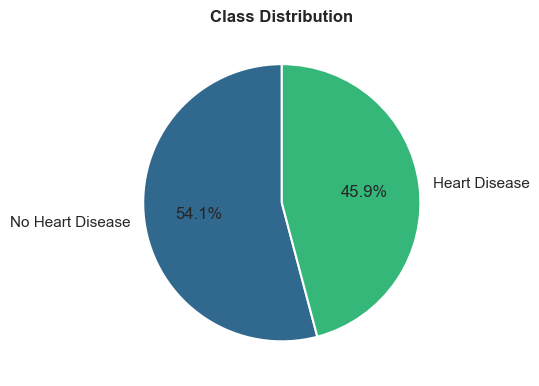

In [6]:
fig, ax = plt.subplots(figsize=(5, 4.5))
counts = df["target"].value_counts().sort_index()
ax.pie(counts, labels=["No Heart Disease", "Heart Disease"], autopct="%1.1f%%",
       colors=sns.color_palette("viridis", 2), startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Class Distribution", fontweight="bold")
plt.show()


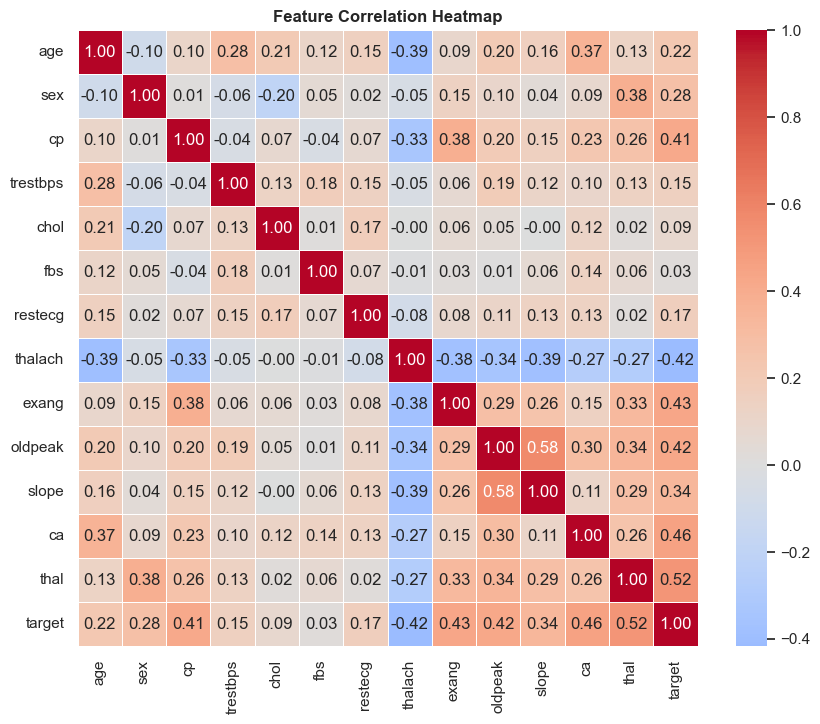

In [7]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontweight="bold")
plt.show()


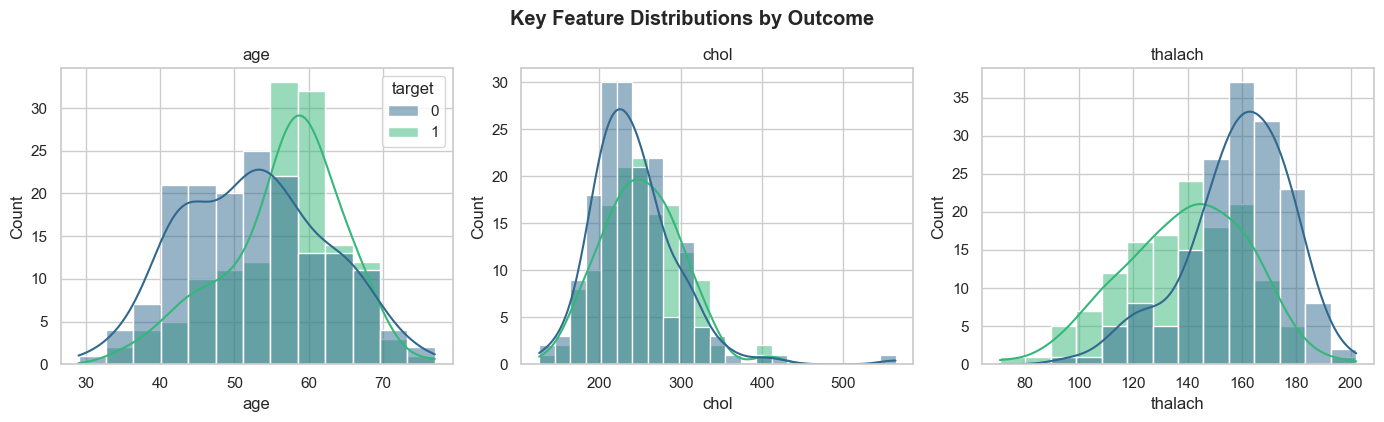

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["age", "chol", "thalach"]):
    sns.histplot(data=df, x=col, hue="target", kde=True, ax=ax, palette="viridis", legend=(col == "age"))
    ax.set_title(col)
plt.tight_layout()
plt.suptitle("Key Feature Distributions by Outcome", y=1.05, fontweight="bold")
plt.show()


**Observations:** Patients with heart disease tend to have a lower maximum heart rate achieved (`thalach`) during exercise testing — this matches real cardiology knowledge, since a healthy heart can typically pump faster under exertion.

## 4. Train / test split & feature scaling

Same approach as before: 80% of patients for training, 20% held out purely for honest testing, with all features scaled to the same numeric range.

In [9]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 242, Test size: 61



## The six algorithms we'll compare

| Algorithm | Intuition | Strength |
|---|---|---|
| **Logistic Regression** | Fits a straight "decision boundary" using a weighted sum of features, squashed into a 0–1 probability. | Simple, fast, very interpretable. Good baseline. |
| **Decision Tree** | Asks a series of yes/no questions about feature values to split the data into purer and purer groups. | Easy to visualize; captures non-linear patterns. |
| **Random Forest** | Trains *many* decision trees on random subsets of data/features and averages their votes. | Reduces overfitting vs. a single tree; usually very strong. |
| **K-Nearest Neighbors (KNN)** | Looks at the *k* most similar patients (by feature distance) and takes a majority vote. | No training phase; intuitive "find similar cases" logic. |
| **Support Vector Machine (SVM)** | Finds the boundary that maximizes the margin (gap) between the two classes. | Effective in higher-dimensional feature spaces. |
| **Gradient Boosting** | Builds trees sequentially, where each new tree focuses on correcting the previous trees' mistakes. | Often the most accurate, at the cost of some interpretability. |

We will not just pick one — we'll **train all six, score them fairly on the same held-out test set, and let the data tell us which one wins.**



## How we judge the models

A single "accuracy" number can be misleading for medical data, especially when classes are imbalanced. We track five metrics:

- **Accuracy** — % of all predictions that were correct.
- **Precision** — Of everyone we *predicted* has the disease, what % actually do? (high precision = few false alarms)
- **Recall (Sensitivity)** — Of everyone who *actually* has the disease, what % did we catch? (high recall = few missed cases)
- **F1 Score** — The harmonic mean of precision and recall; a balanced single number.
- **ROC-AUC** — How well the model ranks positive cases above negative cases across *all* possible thresholds (1.0 = perfect, 0.5 = random guessing).

For medical screening tools, **recall is often the most important metric** — missing a sick patient (a false negative) is usually far more costly than a false alarm that gets ruled out with a follow-up test. We'll keep this in mind when picking our final model, not just chase the single highest number.


In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=9),
    "Support Vector Machine": SVC(kernel="rbf", probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

results = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1 Score": f1_score(y_test, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,K-Nearest Neighbors,0.901639,0.823529,1.000000,0.903226,0.958333
1,Random Forest,0.901639,0.843750,0.964286,0.900000,0.955087
2,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
3,Gradient Boosting,0.852459,0.787879,0.928571,0.852459,0.945887
4,Support Vector Machine,0.852459,0.806452,0.892857,0.847458,0.943723
5,Decision Tree,0.770492,0.705882,0.857143,0.774194,0.803030


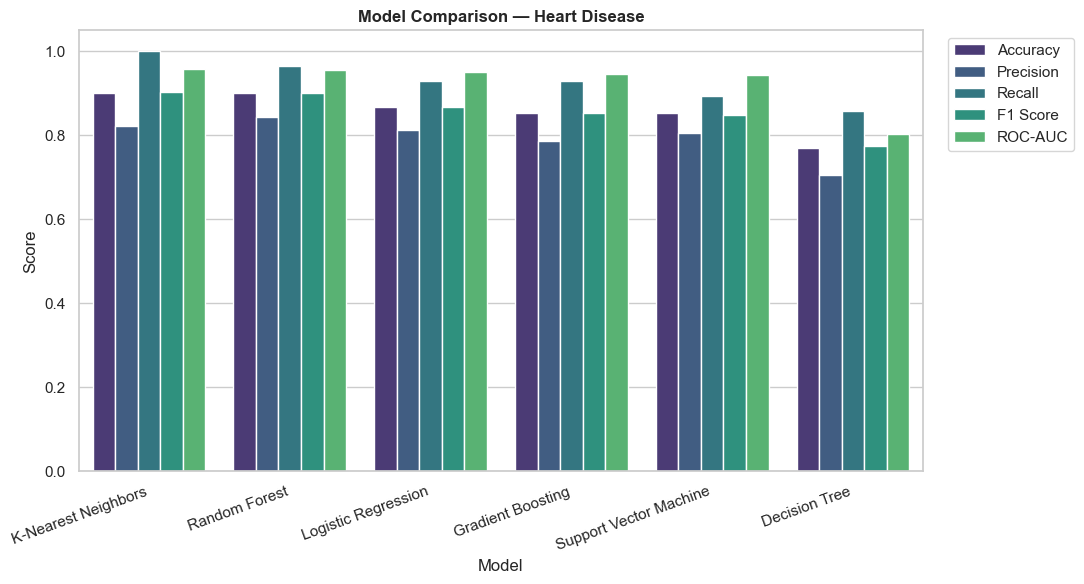

In [11]:
melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(11, 6))
sns.barplot(data=melted, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1.05)
plt.title("Model Comparison — Heart Disease", fontweight="bold")
plt.xticks(rotation=20, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 5. Evaluate the best model in detail

Best model: K-Nearest Neighbors


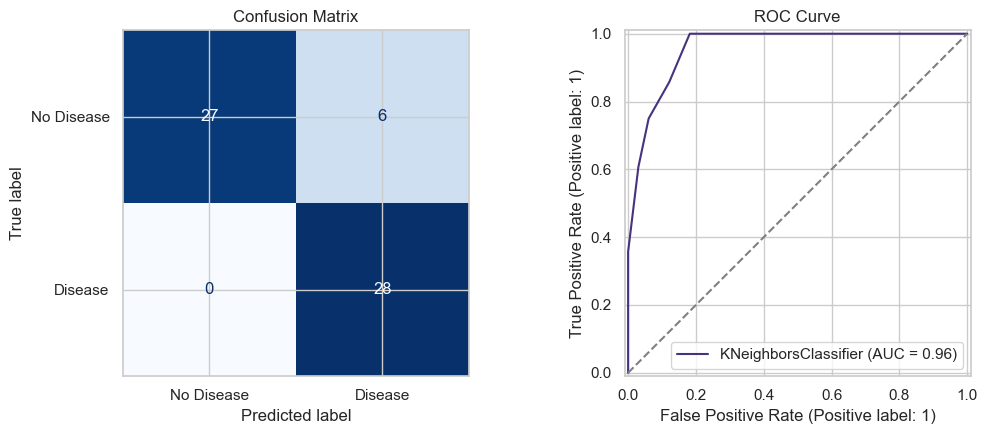

In [12]:
best_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_name]
print(f"Best model: {best_name}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_estimator(best_model, X_test_scaled, y_test,
                                       display_labels=["No Disease", "Disease"],
                                       cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")
RocCurveDisplay.from_estimator(best_model, X_test_scaled, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[1].set_title("ROC Curve")
plt.tight_layout()
plt.show()


In [13]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importances = np.abs(best_model.coef_[0])
else:
    importances = None

if importances is not None:
    imp_df = pd.DataFrame({"Feature": X.columns, "Importance": importances}).sort_values("Importance", ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(data=imp_df, x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False)
    plt.title(f"Feature Importance ({best_name})", fontweight="bold")
    plt.tight_layout()
    plt.show()


## 6. Save the model for the web app

In [14]:
import json

joblib.dump(best_model, "../models/heart_model.joblib")
joblib.dump(scaler, "../models/heart_scaler.joblib")
with open("../models/heart_metadata.json", "w") as f:
    json.dump({
        "disease": "Heart Disease",
        "best_model": best_name,
        "metrics": results_df.iloc[0].to_dict(),
        "class_names": ["No Heart Disease", "Heart Disease"],
        "feature_names": list(X.columns),
    }, f, indent=2)

print("Saved model, scaler, and metadata to ../models/")


Saved model, scaler, and metadata to ../models/



## Conclusion & next steps

- We cleaned the raw data, explored it visually, and trained **six different algorithms** under identical, fair conditions.
- **the best-performing model (see results table above)** came out on top for this dataset, balancing accuracy, recall, and ROC-AUC.
- The trained model + scaler have been saved to `models/heart_model.joblib` and `models/heart_scaler.joblib`, ready to be loaded by the Streamlit web app (`app/app.py`).

### Ideas to extend this project further
- Try hyperparameter tuning with `GridSearchCV` or `RandomizedSearchCV` to squeeze out more performance.
- Try `SMOTE` (from the `imbalanced-learn` library) if you want to address class imbalance more aggressively.
- Collect a larger, more diverse dataset — small datasets like this one risk overfitting to quirks of the sample.
- Add SHAP value explanations so the model can justify *why* it made a particular prediction (very important for medical trust).

> ⚠️ **Disclaimer:** This model is an educational/portfolio project, not a certified medical device. It should never be used for real clinical decision-making without rigorous validation, regulatory approval, and physician oversight.
